# Retention Modeling - First Purchase Behavior

### 🔎 Overview
This notebook attempts to predict customer retention using only the signals from the customer's first purchase. The goal is to identify early which customers are likely to become high-engagement buyers. If successful, this would allow the business to step in at the right moment with targeted actions to keep customers engaged and improve long-term retention.


### 🎯 Prediction Task
The target variable is defined in the notebook `01_ecommerce_data_preparation.ipynb` as:

* **Retention** = 1 if a customer placed 3 or more orders within 6 months of their first purchase
* **Retention** = 0 otherwise

The target distribution is approximately balanced (~50:50), making it suitable for standard binary classification without resampling.

### 🗂️ Dataset
The modeling dataset contains one row per customer, with features derived exclusively from their first purchase day. This strict constraint ensures no data leakage — only information available at the time of the first transaction is used to make predictions. Features include transactional signals (spend, quantity, discount), behavioral metrics (session duration, pages viewed), and demographic information (age, gender, city).


### 🤖 Modeling Approach
Four classifiers are trained and evaluated using 5-fold cross-validation on the training set, with ROC-AUC as the primary metric:

* **Logistic Regression** — linear baseline
* **Random Forest** — ensemble, handles non-linearity
* **XGBoost** — gradient boosting, industry standard for tabular data
* **CatBoost** — handles categorical features natively, strong out-of-the-box performance


In [115]:
# import libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [93]:
# Display all columns
pd.set_option('display.max_columns', None)

In [94]:
# Load the datasets
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data" / "cleaned"

retention_data = pd.read_csv(DATA_DIR / "customer_retention_modeling_dataset.csv")
retention_data 

,index,Customer_ID,First_Purchase_Date,Age,Gender,City,Is_Returning_Customer,Year,Month,Quarter,Weekday,Weekday_Name,Month_Name,Is_Weekend,Six_Months_Window,Total_Spend,Total_Quantity,Total_Discount,Avg_Discount_Rate,Avg_Session_Duration_Minutes,Avg_Pages_Viewed,Avg_Customer_Rating,Avg_Delivery_Time_Days,Num_First_Day_Orders,Product_Category,Payment_Method,Device_Type,Avg_Price_Per_Item,Discount_Ratio,Engagement_Rate,Retention
0,0,CUST_00001,2023-05-29,40,Male,Ankara,True,2023,5,2,0,Monday,May,False,2023-11-29,29.18,1,0.0,0.0,14.0,9.0,4.0,13.0,1,Books,Digital Wallet,Mobile,29.18,0.0,0.643,1
1,1,CUST_00002,2023-02-27,33,Male,Istanbul,True,2023,2,1,0,Monday,February,False,2023-08-27,332.34,2,0.0,0.0,3.0,8.0,5.0,8.0,1,Fashion,Debit Card,Mobile,166.17,0.0,2.667,1
2,2,CUST_00003,2023-01-13,42,Male,Konya,False,2023,1,1,4,Friday,January,False,2023-07-13,66.44,1,0.0,0.0,9.0,5.0,5.0,3.0,1,Food,Debit Card,Desktop,66.44,0.0,0.556,0
3,3,CUST_00004,2024-01-15,53,Male,Izmir,False,2024,1,1,0,Monday,January,False,2024-07-15,112.65,1,0.0,0.0,9.0,6.0,4.0,5.0,1,Food,Bank Transfer,Mobile,112.65,0.0,0.667,0
4,4,CUST_00005,2023-03-16,32,Male,Ankara,False,2023,3,1,3,Thursday,March,False,2023-09-16,1601.01,3,0.0,0.0,12.0,8.0,5.0,5.0,1,Home & Garden,Bank Transfer,Mobile,533.67,0.0,0.667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,CUST_04996,2023-07-07,34,Male,Antalya,False,2023,7,3,4,Friday,July,False,2024-01-07,341.38,2,0.0,0.0,18.0,7.0,3.0,8.0,1,Sports,Bank Transfer,Mobile,170.69,0.0,0.389,1
4996,4996,CUST_04997,2023-01-31,43,Female,Adana,True,2023,1,1,1,Tuesday,January,False,2023-07-31,148.68,2,0.0,0.0,20.0,12.0,4.0,4.0,1,Fashion,Debit Card,Tablet,74.34,0.0,0.600,0
4997,4997,CUST_04998,2023-04-27,72,Female,Kayseri,False,2023,4,2,3,Thursday,April,False,2023-10-27,482.90,5,0.0,0.0,9.0,8.0,3.0,12.0,1,Toys,Credit Card,Desktop,96.58,0.0,0.889,0
4998,4998,CUST_04999,2023-10-12,44,Male,Antalya,False,2023,10,4,3,Thursday,October,False,2024-04-12,6036.70,5,0.0,0.0,7.0,18.0,5.0,7.0,1,Electronics,Digital Wallet,Desktop,1207.34,0.0,2.571,0


In [95]:
# Drop columns 
retention_data = retention_data.drop(columns = ['index', 'Is_Returning_Customer'])
retention_data

,Customer_ID,First_Purchase_Date,Age,Gender,City,Year,Month,Quarter,Weekday,Weekday_Name,Month_Name,Is_Weekend,Six_Months_Window,Total_Spend,Total_Quantity,Total_Discount,Avg_Discount_Rate,Avg_Session_Duration_Minutes,Avg_Pages_Viewed,Avg_Customer_Rating,Avg_Delivery_Time_Days,Num_First_Day_Orders,Product_Category,Payment_Method,Device_Type,Avg_Price_Per_Item,Discount_Ratio,Engagement_Rate,Retention
0,CUST_00001,2023-05-29,40,Male,Ankara,2023,5,2,0,Monday,May,False,2023-11-29,29.18,1,0.0,0.0,14.0,9.0,4.0,13.0,1,Books,Digital Wallet,Mobile,29.18,0.0,0.643,1
1,CUST_00002,2023-02-27,33,Male,Istanbul,2023,2,1,0,Monday,February,False,2023-08-27,332.34,2,0.0,0.0,3.0,8.0,5.0,8.0,1,Fashion,Debit Card,Mobile,166.17,0.0,2.667,1
2,CUST_00003,2023-01-13,42,Male,Konya,2023,1,1,4,Friday,January,False,2023-07-13,66.44,1,0.0,0.0,9.0,5.0,5.0,3.0,1,Food,Debit Card,Desktop,66.44,0.0,0.556,0
3,CUST_00004,2024-01-15,53,Male,Izmir,2024,1,1,0,Monday,January,False,2024-07-15,112.65,1,0.0,0.0,9.0,6.0,4.0,5.0,1,Food,Bank Transfer,Mobile,112.65,0.0,0.667,0
4,CUST_00005,2023-03-16,32,Male,Ankara,2023,3,1,3,Thursday,March,False,2023-09-16,1601.01,3,0.0,0.0,12.0,8.0,5.0,5.0,1,Home & Garden,Bank Transfer,Mobile,533.67,0.0,0.667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST_04996,2023-07-07,34,Male,Antalya,2023,7,3,4,Friday,July,False,2024-01-07,341.38,2,0.0,0.0,18.0,7.0,3.0,8.0,1,Sports,Bank Transfer,Mobile,170.69,0.0,0.389,1
4996,CUST_04997,2023-01-31,43,Female,Adana,2023,1,1,1,Tuesday,January,False,2023-07-31,148.68,2,0.0,0.0,20.0,12.0,4.0,4.0,1,Fashion,Debit Card,Tablet,74.34,0.0,0.600,0
4997,CUST_04998,2023-04-27,72,Female,Kayseri,2023,4,2,3,Thursday,April,False,2023-10-27,482.90,5,0.0,0.0,9.0,8.0,3.0,12.0,1,Toys,Credit Card,Desktop,96.58,0.0,0.889,0
4998,CUST_04999,2023-10-12,44,Male,Antalya,2023,10,4,3,Thursday,October,False,2024-04-12,6036.70,5,0.0,0.0,7.0,18.0,5.0,7.0,1,Electronics,Digital Wallet,Desktop,1207.34,0.0,2.571,0


In [97]:
# Convert to datetime
retention_data['First_Purchase_Date'] = pd.to_datetime(retention_data['First_Purchase_Date'])

# Filter censored customers (ensure full 6-month observation window)
latest_date = retention_data['First_Purchase_Date'].max()
cutoff_date = latest_date - pd.DateOffset(months=6)

eligible_customers = retention_data[retention_data['First_Purchase_Date'] <= cutoff_date].copy()

print(f"Latest date in data:            {latest_date}")
print(f"Cutoff date:                    {cutoff_date}")
print(f"Customers with reliable labels: {len(eligible_customers)}")
print(f"Customers removed (censored):   {len(retention_data) - len(eligible_customers)}")
print(f"Retention rate:                 {eligible_customers['Retention'].mean():.3f}")

# Time-based train/test split (chosen to be approximately 80/20 split for train/test)
split_date = pd.Timestamp("2023-06-01")

train_data = eligible_customers[eligible_customers['First_Purchase_Date'] <  split_date].copy()
test_data  = eligible_customers[eligible_customers['First_Purchase_Date'] >= split_date].copy()

print(f"\nTrain/test split date: {split_date}")
print(f"Train size: {len(train_data)}, retention rate: {train_data['Retention'].mean():.3f}")
print(f"Test size:  {len(test_data)},  retention rate: {test_data['Retention'].mean():.3f}")

# Split features and target
X_train = train_data.drop(columns=['Retention', 'First_Purchase_Date'])
y_train = train_data['Retention']
X_test  = test_data.drop(columns=['Retention', 'First_Purchase_Date'])
y_test  = test_data['Retention']

Latest date in data:            2024-03-16 00:00:00
Cutoff date:                    2023-09-16 00:00:00
Customers with reliable labels: 4702
Customers removed (censored):   298
Retention rate:                 0.494

Train/test split date: 2023-06-01 00:00:00
Train size: 3868, retention rate: 0.492
Test size:  834,  retention rate: 0.506


In [98]:
print(f"Train retention rate: {y_train.mean():.3f}")
print(f"Test retention rate:  {y_test.mean():.3f}")

Train retention rate: 0.492
Test retention rate:  0.506


The **retention rate** is consistent between train (49.2%) and test (50.6%) sets — confirming no significant temporal drift in the target variable. The split is approximately 80:20 for the chosen cutoff date (June 1, 2023).

Before dropping redundant and collinear columns, I inspect the feature types in the cell below to identify categorical and numerical columns.

In [99]:
# Check the data types for columns
print(X_train.dtypes)

Customer_ID                      object
Age                               int64
Gender                           object
City                             object
Year                              int64
Month                             int64
Quarter                           int64
Weekday                           int64
Weekday_Name                     object
Month_Name                       object
Is_Weekend                         bool
Six_Months_Window                object
Total_Spend                     float64
Total_Quantity                    int64
Total_Discount                  float64
Avg_Discount_Rate               float64
Avg_Session_Duration_Minutes    float64
Avg_Pages_Viewed                float64
Avg_Customer_Rating             float64
Avg_Delivery_Time_Days          float64
Num_First_Day_Orders              int64
Product_Category                 object
Payment_Method                   object
Device_Type                      object
Avg_Price_Per_Item              float64


In [100]:
def compute_vif(X):
    """Compute VIF for all numerical features after one-hot encoding."""
    X_encoded = pd.get_dummies(X, drop_first=True).astype(float)
    X_encoded = X_encoded.loc[:, X_encoded.std() > 0]
    X_encoded = X_encoded.loc[:, ~X_encoded.T.duplicated()]
    
    return pd.DataFrame({
        'Feature': X_encoded.columns,
        'VIF': [variance_inflation_factor(X_encoded.values, i)
                for i in range(X_encoded.shape[1])]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

# Drop leakage, redundant and constant columns
cols_to_drop = ['Customer_ID', 'Six_Months_Window', 'Weekday_Name',
                'Month_Name', 'Quarter', 'Is_Weekend', 'Year', 
                'Month', 'Weekday', 'Discount_Ratio', 'Num_First_Day_Orders']

X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

# Calculate VIF
print("── VIF Before Multicollinearity Treatment ──")
compute_vif(X_train)

── VIF Before Multicollinearity Treatment ──


,Feature,VIF
0,Avg_Pages_Viewed,15.777272
1,Avg_Session_Duration_Minutes,11.364483
2,Avg_Customer_Rating,10.795443
3,Age,9.911163
4,Avg_Price_Per_Item,8.320536
5,Total_Spend,6.610007
6,Total_Quantity,6.163249
7,Payment_Method_Credit Card,4.560008
8,Avg_Delivery_Time_Days,4.393442
9,City_Istanbul,3.826072


In [101]:
# Drop high-VIF columns identified above
high_vif_cols = ['Avg_Pages_Viewed', 'Avg_Customer_Rating']

X_train = X_train.drop(columns=high_vif_cols)
X_test  = X_test.drop(columns=high_vif_cols)

# Confirm VIF is <10 for all features
print("── VIF After Multicollinearity Treatment ──")
compute_vif(X_train)

── VIF After Multicollinearity Treatment ──


,Feature,VIF
0,Age,9.590611
1,Avg_Session_Duration_Minutes,9.587169
2,Avg_Price_Per_Item,8.284661
3,Total_Spend,6.581154
4,Total_Quantity,6.013486
5,Payment_Method_Credit Card,4.424839
6,Avg_Delivery_Time_Days,4.338849
7,City_Istanbul,3.696442
8,Product_Category_Electronics,3.279771
9,Payment_Method_Debit Card,3.121783


In [107]:
def get_column_types(X):
    """Return categorical and numerical column lists."""
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    print("Categorical:", cat_cols)
    print("\n")
    print("Numerical:",   num_cols)
    return cat_cols, num_cols

# Update the lists of columns
cat_cols, num_cols = get_column_types(X_train)

Categorical: ['Gender', 'City', 'Product_Category', 'Payment_Method', 'Device_Type']


Numerical: ['Age', 'Total_Spend', 'Total_Quantity', 'Total_Discount', 'Avg_Discount_Rate', 'Avg_Session_Duration_Minutes', 'Avg_Delivery_Time_Days', 'Avg_Price_Per_Item', 'Engagement_Rate']


`Avg_Pages_Viewed` (VIF = 15.8) is dropped due to high multicollinearity with `Avg_Session_Duration_Minutes` — their relationship is already captured by the engineered Engagement_Rate feature. `Avg_Customer_Rating` (VIF = 10.8) is borderline but dropped to ensure a clean feature set for Logistic Regression. All remaining features have VIF < 10, making the feature set suitable for all four models. Note that tree-based models (Random Forest, XGBoost, CatBoost) are not sensitive to multicollinearity — this check primarily benefits the linear baseline.

In [108]:
def get_preprocessor(num_cols, cat_cols):
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ])

def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest':       RandomForestClassifier(random_state=42),
        'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss'),
        'CatBoost':            CatBoostClassifier(random_state=42, verbose=False)
    }

def run_cross_validation(X, y, num_cols, cat_cols, cv=5):
    preprocessor = get_preprocessor(num_cols, cat_cols)
    results = {}
    for name, model in get_models().items():
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
        results[name] = scores
        print(f"{name}: ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")
    return results

# Baseline cross-validation
print("── Baseline Cross-Validation Results ──")
cv_results = run_cross_validation(X_train, y_train, num_cols, cat_cols)

── Baseline Cross-Validation Results ──
Logistic Regression: ROC-AUC = 0.5176 ± 0.0151
Random Forest: ROC-AUC = 0.5171 ± 0.0162
XGBoost: ROC-AUC = 0.5095 ± 0.0206
CatBoost: ROC-AUC = 0.5266 ± 0.0198


The CatBoost model performs marginally better than others, however all of the models have a value of ROC-AUC slightly higher than 0.5, indicating performance near random chance. This is consistent with EDA findings where first-purchase behavioral signals showed near-zero correlation with retention. The fundamental limitation is that a single purchase contains insufficient information to reliably predict long-term customer loyalty. For first-purchase retention prediction to work well richer behavioral signals are needed, such as how customers found the store (organic search, ad, referral), whether they created an account or checked out as guest, how long they spent comparing products before buying, whether they opened post-purchase emails etc.


This finding itself is a valid business insight — investing in retention prediction models based solely on first-purchase data is unlikely to yield actionable results.

Despite near-random baseline performance, feature engineering is attempted to explore whether interaction effects between features might reveal hidden signal not captured by individual variables. The following interaction features are motivated by domain reasoning: spending per item as a proxy for purchase intent, discount sensitivity relative to spend, and engagement quality weighted by revenue.

In [110]:
# Feature engineering
def create_features(df):
    df = df.copy()
    df['Spend_per_Item']     = df['Total_Spend'] / (df['Total_Quantity'] + 1e-6)
    df['Discount_x_Spend']   = df['Avg_Discount_Rate'] * df['Total_Spend']
    df['Engagement_x_Spend'] = df['Engagement_Rate'] * df['Total_Spend']
    return df

X_train_eng = create_features(X_train)
X_test_eng  = create_features(X_test)

cat_cols_eng, num_cols_eng = get_column_types(X_train_eng)

print("\n── Feature Engineered Cross-Validation Results ──")
cv_results_eng = run_cross_validation(X_train_eng, y_train, num_cols_eng, cat_cols_eng)

Categorical: ['Gender', 'City', 'Product_Category', 'Payment_Method', 'Device_Type']


Numerical: ['Age', 'Total_Spend', 'Total_Quantity', 'Total_Discount', 'Avg_Discount_Rate', 'Avg_Session_Duration_Minutes', 'Avg_Delivery_Time_Days', 'Avg_Price_Per_Item', 'Engagement_Rate', 'Spend_per_Item', 'Discount_x_Spend', 'Engagement_x_Spend']

── Feature Engineered Cross-Validation Results ──
Logistic Regression: ROC-AUC = 0.5165 ± 0.0139
Random Forest: ROC-AUC = 0.5135 ± 0.0274
XGBoost: ROC-AUC = 0.5163 ± 0.0244
CatBoost: ROC-AUC = 0.5281 ± 0.0190


The comparison between baseline and feature-engineered models is given in the table below:

$$
\begin{array}{lcc}
\hline
\textbf{Model} & \textbf{Baseline ROC-AUC} & \textbf{Feature Engineered ROC-AUC} \\
\hline
\text{Logistic Regression} & 0.5176 \pm 0.0151 & 0.5165 \pm 0.0139 \\
\text{Random Forest} & 0.5171 \pm 0.0162 & 0.5135 \pm 0.0274 \\
\text{XGBoost} & 0.5095 \pm 0.0206 & 0.5163 \pm 0.0244 \\
\text{CatBoost} & 0.5266 \pm 0.0198 & 0.5281 \pm 0.0190 \\
\hline
\end{array}
$$

Feature engineering did not meaningfully improve performance — most changes are within the standard deviation and thus likely not statistically significant, with slight gains for XGBoost and CatBoost but degradation for Random Forest. Overall, this confirms the earlier assumption that the limitation lies in the data and feature relevance rather than model choice. 

The following code with plotted ROC curve and confusion matrix is included for completion purposes, to illustrate the model's behaviour on unseen data as a standard reporting step.

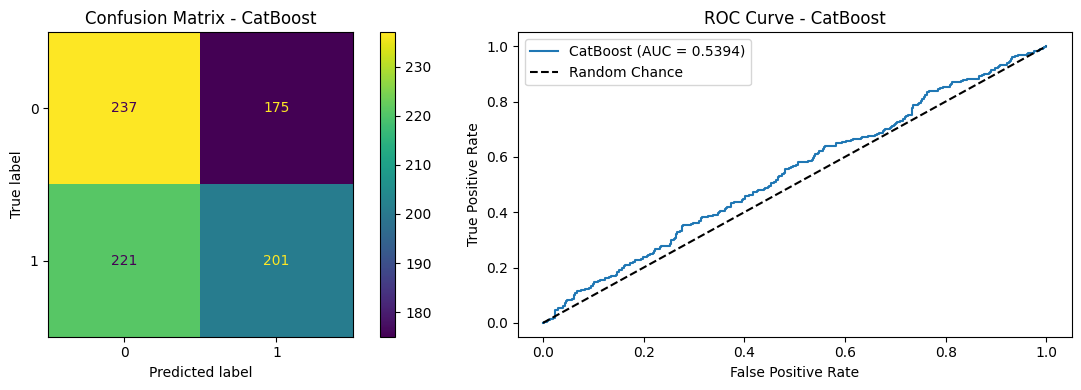

In [112]:
# Final evaluation on test set with best model (CatBoost)
best_pipeline = Pipeline(steps=[
    ('preprocessor', get_preprocessor(num_cols, cat_cols)),
    ('model', CatBoostClassifier(random_state=42, verbose=False))
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
axes[0].set_title('Confusion Matrix - CatBoost')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'CatBoost (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Chance')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - CatBoost')
axes[1].legend()

plt.tight_layout()
plt.show()

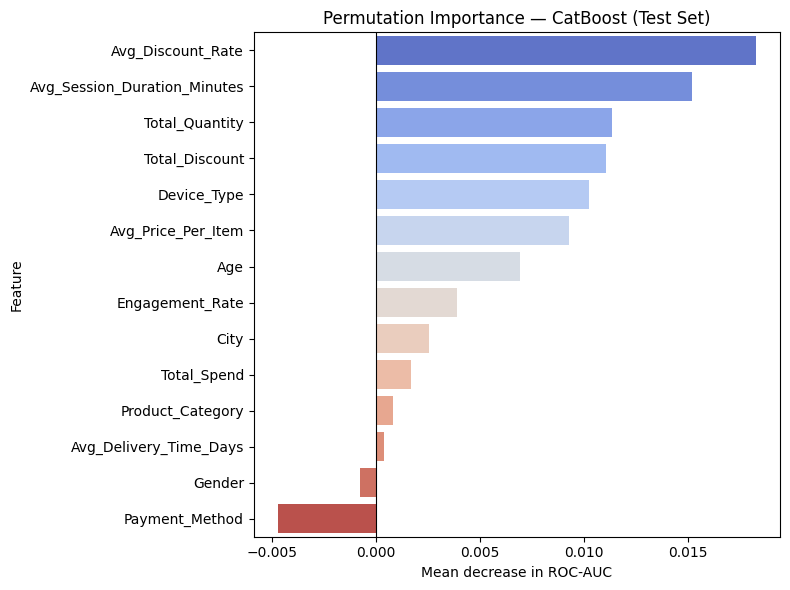

In [118]:
perm_result = permutation_importance(
    best_pipeline, X_test, y_test,
    n_repeats=10,
    scoring='roc_auc',
    random_state=42
)

perm_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_df, x='Importance', y='Feature', 
            hue='Feature', palette='coolwarm', legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Permutation Importance — CatBoost (Test Set)')
plt.xlabel('Mean decrease in ROC-AUC')
plt.tight_layout()
plt.show()

Despite near-random cross-validation performance (ROC-AUC ≈ 0.52), permutation importance reveals that some features do carry marginal signal. `Avg_Discount_Rate` (0.018) and `Avg_Session_Duration_Minutes` (0.015) show the highest importance, suggesting weak but non-zero associations with retention. However, the magnitudes are extremely small compared to what a well-performing model would show, and the standard deviations overlap zero for most features — meaning the importance estimates are noisy and unreliable.

Notably, `Payment_Method` (-0.005) and `Gender` (-0.001) show negative importance, meaning permuting them slightly *improves* model performance — a strong signal that these features add noise rather than signal. `Total_Spend` and `Product_Category` are essentially zero.

Overall, no single feature meaningfully moves the needle, confirming that the predictive limitation is inherent to the data rather than the model or feature engineering choices.

## Key Takeaways

* **All four models (Logistic Regression, Random Forest, XGBoost, CatBoost) performed near random chance** (ROC-AUC ≈ 0.51–0.53), with CatBoost marginally best at 0.5266.
* Feature engineering using domain-motivated interaction features provided no meaningful improvement, confirming the limitation lies in the data rather than model choice or feature representation.
* A VIF analysis identified and resolved multicollinearity among discount-related features (Discount_Ratio) and engagement features (Avg_Pages_Viewed), improving feature set suitability for Logistic Regression.
* The fundamental limitation is that a **single purchase transaction contains insufficient behavioral signal to reliably predict long-term customer loyalty**. This is itself a valid and actionable business insight — predictive retention models based solely on first-purchase data are unlikely to yield reliable results.
* Richer signals such as early repeat visit behavior, marketing engagement, or account creation status would be needed to make this prediction task tractable.

## Next Steps

* Notebook 04 will redefine the prediction task using the full customer purchase history, leveraging features such as purchase frequency, recency, monetary value, and time between purchases — signals shown in EDA to have much stronger correlation with retention.
* A customer segmentation analysis (clustering) is planned as a separate notebook to identify actionable customer groups based on behavioral patterns.

## 🪞 Reflection

When I first designed this notebook, I expected behavioral features like session duration and pages viewed to carry some predictive power. The near-zero point-biserial correlations from EDA should have been a warning sign — but I proceeded with modeling to confirm empirically, and all four models told the same story.
Predicting long-term loyalty from a single transaction is like predicting a friendship from a first handshake — the signal simply isn't there yet. A negative result, if understood clearly, is still a result: don't invest in this type of model without richer behavioral data.